# 03 · EDA — `tabla_modelo.csv`

Análisis exploratorio de la tabla de modelado del estudio causal
**`nivel_sequia_max → rendimiento_real`**.

Grano: **municipio × año agrícola (2016–2024) × ciclo (OI/PV) × modalidad (Riego/Temporal)**.

Guion:

1. Vistazo general y grano
2. Calidad de datos (nulos, llaves, rangos imposibles, cobertura)
3. Resultado — `rendimiento_real`
4. Tratamiento — `nivel_sequia_max` y `nivel_sequia_prev90_max`
5. Tratamiento ↔ resultado (bivariado)
6. Confusores (distribuciones y correlaciones)
7. Chequeo de confusión / balance por nivel de sequía
8. Serie temporal
9. Hallazgos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.axisbelow': True, 'axes.edgecolor': '#888', 'axes.linewidth': 0.8,
})

# --- paleta (job -> color) ------------------------------------------------
C_MODALIDAD = {'Riego': '#3b7dd8', 'Temporal': '#e08214'}   # categórica, 2 identidades CVD-separables
C_CICLO     = {'OI': '#5aa9a3', 'PV': '#8c6bb1'}
C_NEUTRO    = '#4c6b8a'                                     # histogramas de una sola serie
CMAP_SEQ    = 'YlOrRd'                                      # magnitud de sequía (secuencial, 1 hue)
CMAP_DIV    = 'RdBu_r'                                      # correlaciones / anomalías (divergente + gris)

RUTA = Path('/Users/jaydymarchan/Desktop/causalidad/data/02_processed/tabla_modelo.csv')
df = pd.read_csv(RUTA)
print(df.shape)
df.head()


(40267, 56)


,anio,idestado,idmunicipio,nomcicloproductivo,nommodalidad,nomestado,nommunicipio,volumenproduccion,cosechada,siniestrada,sembrada,valorproduccion,precio_mean,precio_total,rendimiento_real,tasa_siniestro,nivel_sequia_max,nivel_sequia_prev90_max,tmean_ciclo,tmin_ciclo_mean,tmax_ciclo_mean,dias_helada,gdd_ciclo,tmean_inicio,tmean_preseason,tmean_prev90,tmean_prev90_normal,tmean_prev90_anom,tmean_normal,tmean_ciclo_anom,tmean_ciclo_anom_z,gdd_normal,gdd_anom,tmean_inicio_anom,tmean_preseason_anom,n_dias_ventana,n_dias_con_dato,n_dias_prev90,ventana_incompleta,prev90_incompleta,altitud_media_m,altitud_min_m,altitud_max_m,altitud_std_m,tiene_acuifero_sobreexplotado,tiene_cuenca_sin_disp,acuifero_disp,cuencas_disp,acuifero_condicion_ok,sequia_no_clasificada,sequia_prev90_no_clasificada,clima_ok,prev90_ok,altitud_ok,hidro_ok,siniestro_ok
0,2016,1,1,PV,Riego,Aguascalientes,Aguascalientes,2247.15,300.0,0.0,300.0,7805071.04,3473.32,3473.32,7.490500,0.000000,0,0,21.546776,14.091694,29.001858,0.0,2113.060,21.827541,16.758167,15.601389,16.496674,-0.895285,21.587001,-0.040225,-0.137596,2120.581250,-7.521250,0.609252,-0.767370,183.0,183.0,90.0,False,False,1921.8,1795.0,2093.0,82.7,0,1,-29.64,249.77,0,False,True,True,True,True,True,True
1,2016,1,1,PV,Temporal,Aguascalientes,Aguascalientes,3350.83,5032.0,13.0,5045.0,11255639.02,3359.06,3359.06,0.665904,0.002577,0,0,21.546776,14.091694,29.001858,0.0,2113.060,21.827541,16.758167,15.601389,16.496674,-0.895285,21.587001,-0.040225,-0.137596,2120.581250,-7.521250,0.609252,-0.767370,183.0,183.0,90.0,False,False,1921.8,1795.0,2093.0,82.7,0,1,-29.64,249.77,0,False,True,True,True,True,True,True
2,2016,1,2,PV,Riego,Aguascalientes,Asientos,3340.00,630.0,0.0,630.0,11690000.00,3500.00,3500.00,5.301587,0.000000,0,0,20.726667,13.286612,28.166721,0.0,1962.980,21.115000,15.843750,14.637056,15.675924,-1.038868,20.852729,-0.126062,-0.390252,1986.326875,-23.346875,0.516055,-0.931624,183.0,183.0,90.0,False,False,2038.4,1973.0,2129.0,43.4,0,1,-29.64,249.77,0,False,True,True,True,True,True,True
3,2016,1,2,PV,Temporal,Aguascalientes,Asientos,2770.00,4525.0,0.0,4525.0,9695000.00,3500.00,3500.00,0.612155,0.000000,0,0,20.726667,13.286612,28.166721,0.0,1962.980,21.115000,15.843750,14.637056,15.675924,-1.038868,20.852729,-0.126062,-0.390252,1986.326875,-23.346875,0.516055,-0.931624,183.0,183.0,90.0,False,False,2038.4,1973.0,2129.0,43.4,0,1,-29.64,249.77,0,False,True,True,True,True,True,True
4,2016,1,3,PV,Riego,Aguascalientes,Calvillo,333.00,58.0,0.0,58.0,1251800.28,3759.16,3759.16,5.741379,0.000000,0,0,22.169973,14.747322,29.592623,0.0,2227.105,22.262951,17.324167,16.173333,16.990083,-0.816750,22.196363,-0.026390,-0.093613,2232.002500,-4.897500,0.602008,-0.656086,183.0,183.0,90.0,False,False,1975.9,1563.0,2402.0,262.0,0,1,-29.64,249.77,0,False,True,True,True,True,True,True


## 1 · Vistazo general

In [2]:
LLAVE = ['idestado', 'idmunicipio', 'anio', 'nomcicloproductivo', 'nommodalidad']

print(f'filas: {len(df):,}   columnas: {df.shape[1]}')
print(f'memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'años   : {sorted(df.anio.unique())}')
print(f'ciclos : {df.nomcicloproductivo.value_counts().to_dict()}')
print(f'modalid: {df.nommodalidad.value_counts().to_dict()}')
print(f'estados: {df.idestado.nunique()}   municipios: {df[["idestado","idmunicipio"]].drop_duplicates().shape[0]}')
print(f'llave única (sin duplicados): {df.duplicated(LLAVE).sum() == 0}')

print('\ntipos de dato:')
print(df.dtypes.value_counts().to_string())


filas: 40,267   columnas: 56
memoria: 26.5 MB
años   : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
ciclos : {'PV': 29488, 'OI': 10779}
modalid: {'Temporal': 24860, 'Riego': 15407}
estados: 32   municipios: 2386
llave única (sin duplicados): True

tipos de dato:
float64    35
int64       8
bool        7
object      6


In [3]:
# describe numérico (traspuesto para leerlo)
num = df.select_dtypes('number').columns
df[num].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
anio,40267.0,2020.01,2.580000e+00,2016.00,2018.00,2020.00,2022.00,2.024000e+03
idestado,40267.0,19.20,7.080000e+00,1.00,14.00,20.00,22.00,3.200000e+01
idmunicipio,40267.0,116.89,1.392900e+02,1.00,23.00,60.00,150.00,5.700000e+02
volumenproduccion,40267.0,6053.81,3.503310e+04,0.00,151.20,731.00,3253.87,1.313070e+06
cosechada,40267.0,1560.78,3.934620e+03,0.00,72.00,380.00,1545.00,1.103720e+05
siniestrada,40267.0,56.15,4.131500e+02,0.00,0.00,0.00,0.00,2.350000e+04
sembrada,40267.0,1616.93,3.988380e+03,0.15,76.50,401.00,1623.00,1.121524e+05
valorproduccion,40267.0,28741419.53,1.676149e+08,0.00,649546.25,3183349.56,14759334.84,7.801014e+09
precio_mean,40250.0,4572.81,1.192210e+03,0.00,3800.00,4264.14,5080.10,1.650000e+04
precio_total,40267.0,4790.79,1.951480e+03,0.00,3806.98,4295.45,5188.80,4.060175e+04


## 2 · Calidad de datos

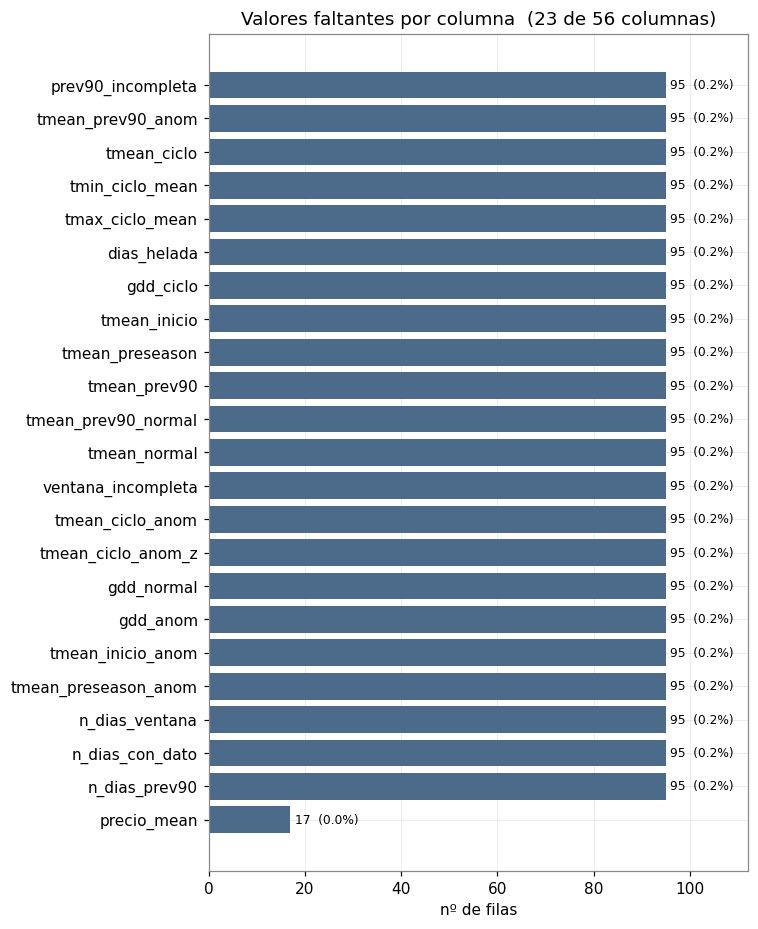

El bloque de 95 filas sin clima = las ventanas de ciclo incompletas en Daymet (clima_ok = False).


In [4]:
# --- 2.1 nulos por columna ---
na = df.isna().sum()
na = na[na > 0].sort_values()
fig, ax = plt.subplots(figsize=(7, 0.35*len(na) + 0.5))
ax.barh(na.index, na.values, color=C_NEUTRO)
ax.bar_label(ax.containers[0], labels=[f'{v}  ({v/len(df):.1%})' for v in na.values], padding=3, fontsize=8)
ax.set_title(f'Valores faltantes por columna  ({len(na)} de {df.shape[1]} columnas)')
ax.set_xlabel('nº de filas'); ax.margins(x=0.18)
plt.tight_layout(); plt.show()

print('El bloque de 95 filas sin clima = las ventanas de ciclo incompletas en Daymet (clima_ok = False).')


In [5]:
# --- 2.2 flags de completitud ---
flags = ['clima_ok', 'prev90_ok', 'altitud_ok', 'hidro_ok']
cob = pd.DataFrame({
    'True':  [df[f].sum() for f in flags],
    'False': [(~df[f]).sum() for f in flags],
}, index=flags)
cob['% ok'] = (cob['True'] / len(df) * 100).round(2)
print(cob.to_string())

apto = df['clima_ok'] & df['prev90_ok'] & df['altitud_ok'] & df['hidro_ok'] & ~df['sequia_no_clasificada']
print(f'\nfilas aptas (todos los bloques ok & sequía clasificada): {apto.sum():,}  ({apto.mean():.1%})')
print(f'sequía no clasificada (imputada a 0): {df["sequia_no_clasificada"].sum():,}  ({df["sequia_no_clasificada"].mean():.1%})')
print(f'sequía prev90 no clasificada        : {df["sequia_prev90_no_clasificada"].sum():,}')

# --- acuifero_condicion_ok: NO es un flag de "fila usable" (no se mete en `apto`), sino un
# aviso de que UNA columna puntual -- tiene_acuifero_sobreexplotado -- no es confiable esos años:
# CONAGUA no publicó la clasificación 'Condición' en los xlsx de 2015 y 2018 (0 de 653 acuíferos
# con dato), así que para los años del panel que caen en esas fuentes el flag sale en 0 SIEMPRE,
# no porque no hubiera sobreexplotación (ver 01_cuencas_acuifero.ipynb).
print('\nacuifero_condicion_ok (¿CONAGUA publicó "Condición" en el año fuente asignado?):')
print(df.groupby('anio')['acuifero_condicion_ok'].mean().round(2).to_string())
_sin_cond = df['acuifero_condicion_ok'] == 0
print(f'\nfilas con acuifero_condicion_ok=0: {_sin_cond.sum():,} ({_sin_cond.mean():.1%})')
print('  -> en esas filas, tiene_acuifero_sobreexplotado = 0 es "sin dato", no "sin sobreexplotación".')
print('  -> años afectados:', sorted(df.loc[_sin_cond, 'anio'].unique()))


             True  False    % ok
clima_ok    40172     95   99.76
prev90_ok   40172     95   99.76
altitud_ok  40267      0  100.00
hidro_ok    40267      0  100.00

filas aptas (todos los bloques ok & sequía clasificada): 36,155  (89.8%)
sequía no clasificada (imputada a 0): 4,021  (10.0%)
sequía prev90 no clasificada        : 10,463

acuifero_condicion_ok (¿CONAGUA publicó "Condición" en el año fuente asignado?):
anio
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
2024    1.0

filas con acuifero_condicion_ok=0: 17,866 (44.4%)
  -> en esas filas, tiene_acuifero_sobreexplotado = 0 es "sin dato", no "sin sobreexplotación".
  -> años afectados: [2016, 2017, 2018, 2019]


In [6]:
# --- 2.3 chequeo del cálculo de rendimiento (SIAP: volumen / superficie cosechada) ---
# 'cosechada' ya es superficie NETA:  sembrada = cosechada + siniestrada
_id_area = (df['sembrada'] - df['cosechada'] - df['siniestrada']).abs()
_rend_ok = np.isclose(df['rendimiento_real'],
                      df['volumenproduccion'] / df['cosechada'].replace(0, np.nan),
                      atol=1e-6, equal_nan=True)
chk = {
    'sembrada != cosechada + siniestrada (>1 ha)': int((_id_area > 1).sum()),
    'rendimiento_real != volumen / cosechada'    : int((~_rend_ok).sum()),
    'rendimiento_real < 0'                        : int((df['rendimiento_real'] < 0).sum()),
    'rendimiento_real == 0 (cosecha total nula)'  : int((df['rendimiento_real'] == 0).sum()),
    'rendimiento_real > 16 t/ha (fuera de rango maíz)': int((df['rendimiento_real'] > 16).sum()),
    'volumenproduccion == 0'                      : int((df['volumenproduccion'] == 0).sum()),
    'precio_mean == 0'                            : int((df['precio_mean'] == 0).sum()),
}
res = pd.Series(chk, name='n_filas').to_frame()
res['%'] = (res['n_filas'] / len(df) * 100).round(2)
print(res.to_string())
print()
print(f"rango de rendimiento_real: [{df['rendimiento_real'].min():.2f}, {df['rendimiento_real'].max():.2f}] t/ha  "
      f"(coherente con maíz; SIAP tope ~15 t/ha)")
print(f"tasa de siniestro (siniestrada/sembrada): media {(df['siniestrada']/df['sembrada'].replace(0,np.nan)).mean():.1%}, "
      f"filas con siniestro total (cosechada==0): {int((df['cosechada']==0).sum())}")


                                                  n_filas     %
sembrada != cosechada + siniestrada (>1 ha)             0  0.00
rendimiento_real != volumen / cosechada               169  0.42
rendimiento_real < 0                                    0  0.00
rendimiento_real == 0 (cosecha total nula)            169  0.42
rendimiento_real > 16 t/ha (fuera de rango maíz)        0  0.00
volumenproduccion == 0                                169  0.42
precio_mean == 0                                      152  0.38

rango de rendimiento_real: [0.00, 13.75] t/ha  (coherente con maíz; SIAP tope ~15 t/ha)
tasa de siniestro (siniestrada/sembrada): media 3.1%, filas con siniestro total (cosechada==0): 169


In [7]:
# --- 2.4 variable de resultado para el análisis ---
# rendimiento_real ya viene limpio (= volumen / cosechada, definición SIAP). Se dejan fuera del
# análisis: (a) las filas de cosecha total nula (rend == 0) y (b) tasa de siniestro >= 50%
# (siniestrada/sembrada) -> `siniestro_ok`, calculado en 02_join_data (ver §2.6-2.8 el porqué).
df['rend'] = df['rendimiento_real'].where((df['rendimiento_real'] > 0) & df['siniestro_ok'])
# winsorizado muy suave por modalidad (p1-p99) para correlaciones robustas
df['rend_w'] = df.groupby('nommodalidad')['rend'].transform(
    lambda s: s.clip(*s.quantile([0.01, 0.99]))
)
print(f"registros con rendimiento > 0            : {int((df['rendimiento_real'] > 0).sum()):,}")
print(f"  + con tasa_siniestro < 50% (rend)       : {int(df['rend'].notna().sum()):,}  ({df['rend'].notna().mean():.1%})")
print(f"cosecha total nula, fuera del análisis: {int((df['rendimiento_real'] == 0).sum())}  |  "
      f"tasa_siniestro >= 50%, fuera del análisis: {int((~df['siniestro_ok']).sum())}")
df.groupby('nommodalidad')[['rendimiento_real', 'rend', 'rend_w']].describe().round(2).T

registros con rendimiento > 0            : 40,098
  + con tasa_siniestro < 50% (rend)       : 39,247  (97.5%)
cosecha total nula, fuera del análisis: 169  |  tasa_siniestro >= 50%, fuera del análisis: 1020


nommodalidad               Riego  Temporal
rendimiento_real count  15407.00  24860.00
                 mean       4.44      1.94
                 std        2.39      1.46
                 min        0.00      0.00
                 25%        2.80      0.98
                 50%        3.68      1.36
                 75%        5.36      2.51
                 max       13.75     10.70
rend             count  15350.00  23897.00
                 mean       4.44      1.98
                 std        2.38      1.46
                 min        0.39      0.03
                 25%        2.80      1.00
                 50%        3.68      1.40
                 75%        5.36      2.56
                 max       13.75     10.70
rend_w           count  15350.00  23897.00
                 mean       4.44      1.97
                 std        2.36      1.43
                 min        1.34      0.35
                 25%        2.80      1.00
                 50%        3.68      1.40
                 75%        5.36      2.56
                 max       11.79      7.70

nomcicloproductivo     OI               PV         
nommodalidad        Riego Temporal   Riego Temporal
anio                                               
2016                686.0    507.0  1015.0   2240.0
2017                679.0    514.0  1034.0   2245.0
2018                684.0    513.0  1008.0   2248.0
2019                684.0    514.0  1038.0   2257.0
2020                670.0    513.0  1026.0   2244.0
2021                675.0    510.0  1028.0   2251.0
2022                685.0    520.0  1042.0   2242.0
2023                694.0    524.0  1061.0   2241.0
2024                674.0    533.0  1024.0   2244.0


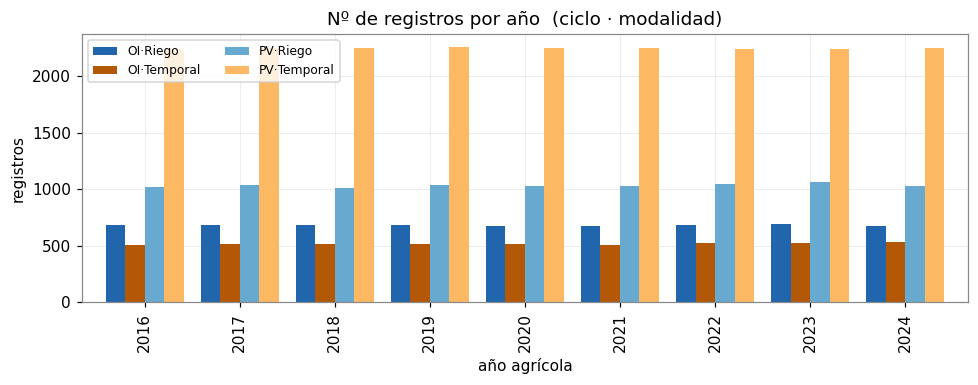

In [8]:
# --- 2.5 cobertura de filas por año x ciclo x modalidad ---
cov = (df.groupby(['anio', 'nomcicloproductivo', 'nommodalidad']).size().rename('n').reset_index())
piv = cov.pivot_table(index='anio', columns=['nomcicloproductivo', 'nommodalidad'], values='n', fill_value=0)
print(piv.to_string())

piv2 = piv.copy()
piv2.columns = [f'{c}·{m}' for c, m in piv2.columns]
_col4 = {'OI·Riego': '#2166ac', 'PV·Riego': '#67a9cf', 'OI·Temporal': '#b35806', 'PV·Temporal': '#fdb863'}
fig, ax = plt.subplots(figsize=(9, 3.6))
piv2.plot(kind='bar', ax=ax, width=0.82, color=[_col4.get(c, '#999') for c in piv2.columns])
ax.set_title('Nº de registros por año  (ciclo · modalidad)')
ax.set_xlabel('año agrícola'); ax.set_ylabel('registros'); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


umbral de siniestro_ok (fijo) = 0.500  -> siniestro_ok=False en 1,020 filas (2.5%)


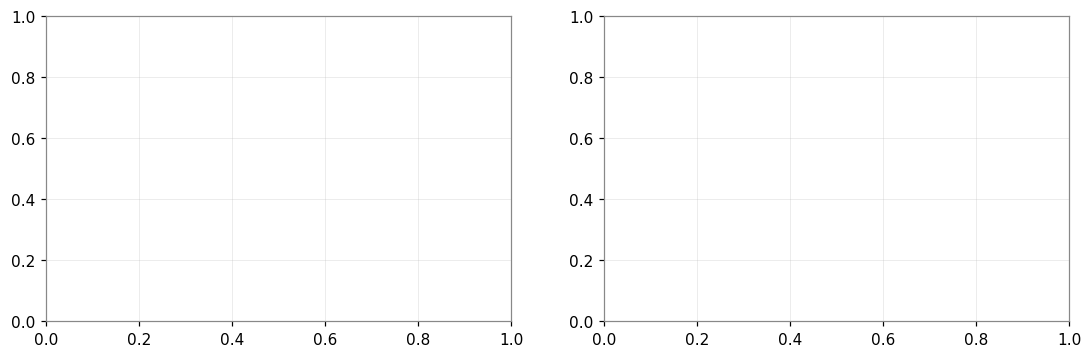

In [9]:
# --- 2.6 · Distribución de la tasa de siniestro (siniestrada / sembrada) ---
# 'tasa_siniestro' y 'siniestro_ok' ya vienen calculadas en 02_join_data (tabla_modelo.csv).
# Punto de corte de Y ELEGIDO: corte FIJO en tasa_siniestro >= 50% (siniestro mayoritario).
UMBRAL_SINIESTRO = 0.50
print(f'umbral de siniestro_ok (fijo) = {UMBRAL_SINIESTRO:.3f}  '
      f'-> siniestro_ok=False en {int((~df["siniestro_ok"]).sum()):,} filas ({(~df["siniestro_ok"]).mean():.1%})')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

In [10]:
# --- 2.7 · Comparación de puntos de corte para Y (elegido: tasa_siniestro >= 50%, corte fijo) ---
# Para cada corte c: se EXCLUYEN las filas con tasa_siniestro >= c y se ve cómo queda `rendimiento_real`.
cortes = [1.01, 1.0, 0.95, 0.90, 0.80, 0.50]   # 1.01 = sin filtro (referencia)
filas = []
for c in cortes:
    excl = df['tasa_siniestro'] >= c
    sub = df.loc[~excl, 'rendimiento_real']
    filas.append(dict(
        corte='sin filtro' if c > 1 else f'>= {c:.0%}',
        n_excluidas=int(excl.sum()), pct_excluidas=excl.mean(),
        n_restante=int((~excl).sum()),
        rend_mediana=sub.median(), rend_media=sub.mean(), rend_std=sub.std(), rend_p95=sub.quantile(.95),
    ))
tabla_cortes = pd.DataFrame(filas)
tabla_cortes['excl_incremental'] = tabla_cortes['n_excluidas'].diff().fillna(tabla_cortes['n_excluidas'].iloc[0]).astype(int)
print(tabla_cortes.round(3).to_string(index=False))

print()
print('Cómo cae la superficie cosechada y el rendimiento según severidad del siniestro:')
bins = [-0.001, 0, 0.2, 0.5, 0.8, 0.95, 1.0]
labels = ['0%', '(0,20%)', '[20,50%)', '[50,80%)', '[80,95%)', '[95,100%]']
df['siniestro_bin'] = pd.cut(df['tasa_siniestro'], bins=bins, labels=labels)
tab_bin = df.groupby('siniestro_bin', observed=True).agg(
    n=('rendimiento_real', 'size'),
    cosechada_mediana=('cosechada', 'median'),
    rend_mediana=('rendimiento_real', 'median'),
    rend_media=('rendimiento_real', 'mean'),
    rend_std=('rendimiento_real', 'std'),
    rend_p95=('rendimiento_real', lambda s: s.quantile(.95)),
)
print(tab_bin.round(2).to_string())


     corte  n_excluidas  pct_excluidas  n_restante  rend_mediana  rend_media  rend_std  rend_p95  excl_incremental
sin filtro            0          0.000       40267          2.39       2.894     2.230     7.800                 0
   >= 100%          169          0.004       40098          2.40       2.906     2.227     7.800               169
    >= 95%          212          0.005       40055          2.40       2.908     2.227     7.800                43
    >= 90%          275          0.007       39992          2.40       2.912     2.227     7.800                63
    >= 80%          435          0.011       39832          2.40       2.920     2.227     7.810               160
    >= 50%         1020          0.025       39247          2.43       2.942     2.229     7.859               585

Cómo cae la superficie cosechada y el rendimiento según severidad del siniestro:


                   n  cosechada_mediana  rend_mediana  rend_media  rend_std  rend_p95
siniestro_bin                                                                        
0%             36481             355.00          2.50        3.00      2.22      7.88
(0,20%)         1789            1919.00          1.55        2.46      2.42      8.57
[20,50%)        1018             521.75          1.10        1.79      1.72      5.45
[50,80%)         560             274.50          0.80        1.34      1.38      4.19
[80,95%)         211              90.00          0.58        0.83      1.02      2.33
[95,100%]        208               0.00          0.00        0.20      0.65      1.00


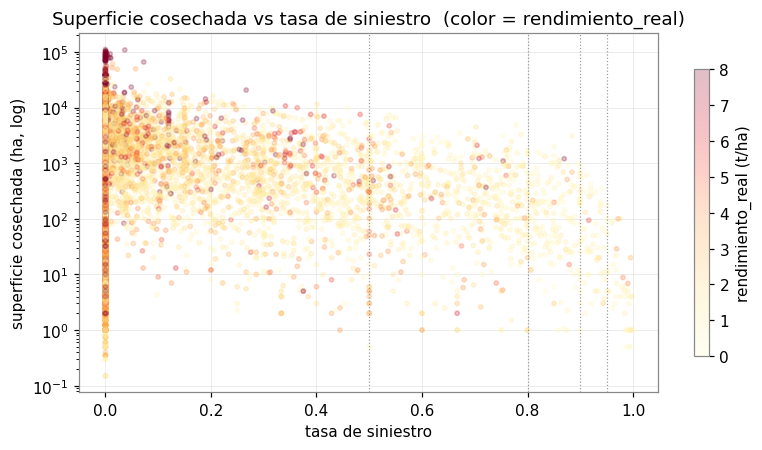

Sugerencia de lectura: a tasa_siniestro >= 90-95% la cosechada mediana cae a pocas decenas
de ha (vs ~390 ha típico) -> el rendimiento de esas filas se apoya en muy poca superficie.

Puntos de corte candidatos para Y (de la tabla de la celda anterior):
     corte  n_excluidas  pct_excluidas  excl_incremental
sin filtro            0       0.000000                 0
   >= 100%          169       0.004197               169
    >= 95%          212       0.005265                43
    >= 90%          275       0.006829                63
    >= 80%          435       0.010803               160
    >= 50%         1020       0.025331               585

`rend` (en esta libreta) excluye cosecha nula Y tasa de siniestro mayoritaria
(tasa_siniestro >= 50%, columna `siniestro_ok` de tabla_modelo.csv).


In [11]:
# --- 2.8 · Superficie cosechada vs tasa de siniestro (¿cuán chica queda el área al recortar?) ---
fig, ax = plt.subplots(figsize=(7.5, 4.2))
m = df['tasa_siniestro'].notna() & (df['cosechada'] > 0)
sc = ax.scatter(df.loc[m, 'tasa_siniestro'], df.loc[m, 'cosechada'],
                s=8, alpha=0.25, c=df.loc[m, 'rendimiento_real'], cmap=CMAP_SEQ, vmin=0, vmax=8)
ax.set_yscale('log')
for q in [0.5, 0.8, 0.9, 0.95]:
    ax.axvline(q, ls=':', color='#999', lw=0.8)
ax.set_xlabel('tasa de siniestro'); ax.set_ylabel('superficie cosechada (ha, log)')
ax.set_title('Superficie cosechada vs tasa de siniestro  (color = rendimiento_real)')
fig.colorbar(sc, ax=ax, shrink=0.8, label='rendimiento_real (t/ha)')
plt.tight_layout(); plt.show()

print('Sugerencia de lectura: a tasa_siniestro >= 90-95% la cosechada mediana cae a pocas decenas')
print('de ha (vs ~390 ha típico) -> el rendimiento de esas filas se apoya en muy poca superficie.')
print()
print('Puntos de corte candidatos para Y (de la tabla de la celda anterior):')
print(tabla_cortes[['corte', 'n_excluidas', 'pct_excluidas', 'excl_incremental']].to_string(index=False))
print()
print(f'`rend` (en esta libreta) excluye cosecha nula Y tasa de siniestro mayoritaria')
print(f'(tasa_siniestro >= {UMBRAL_SINIESTRO:.0%}, columna `siniestro_ok` de tabla_modelo.csv).')


combinaciones municipio-año-ciclo: 30573
nommodalidad
1    20879
2     9694
  -> con las 2 modalidades: 9,694 (31.7%)
  -> con solo 1 modalidad : 20,879 (68.3%)

filas por municipio (máx. teórico 36): min=1, mediana=18, máx=36, media=16.9
municipios con las 36 filas completas: 30 de 2,386 (1.3%)


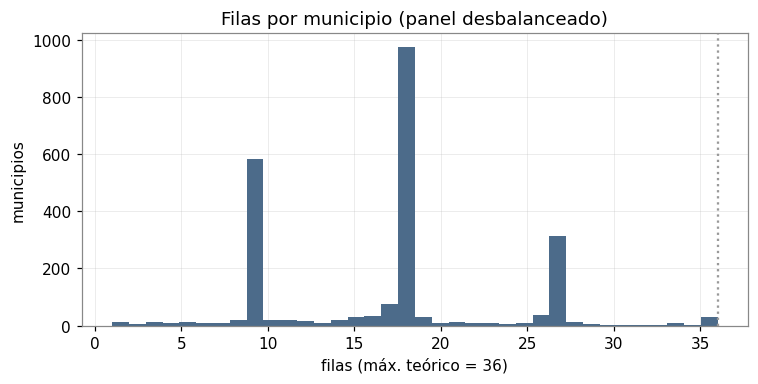


El panel está desbalanceado: la mayoría de los municipios no reportan ambas modalidades
en todos los años/ciclos -> menos variación "dentro de municipio" de la que parece a
primera vista para un modelo con efectos fijos de municipio (ver 04_inferencia_causal).


In [12]:
# --- 2.9 · Completitud del panel (balance) ---
# ¿cuántas combinaciones municipio-año-ciclo tienen las DOS modalidades (Riego y Temporal)?
combos = df.groupby(['idestado', 'idmunicipio', 'anio', 'nomcicloproductivo'])['nommodalidad'].nunique()
print('combinaciones municipio-año-ciclo:', len(combos))
print(combos.value_counts().sort_index().rename('n_combinaciones').to_string())
print(f'  -> con las 2 modalidades: {(combos == 2).sum():,} ({(combos == 2).mean():.1%})')
print(f'  -> con solo 1 modalidad : {(combos == 1).sum():,} ({(combos == 1).mean():.1%})')

# ¿cuántas filas tiene cada municipio? (máximo teórico = 9 años x 2 ciclos x 2 modalidades = 36)
filas_por_muni = df.groupby(['idestado', 'idmunicipio']).size()
print(f"\nfilas por municipio (máx. teórico 36): min={filas_por_muni.min()}, "
      f"mediana={filas_por_muni.median():.0f}, máx={filas_por_muni.max()}, media={filas_por_muni.mean():.1f}")
print(f'municipios con las 36 filas completas: {(filas_por_muni == 36).sum():,} de {len(filas_por_muni):,} '
      f'({(filas_por_muni == 36).mean():.1%})')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(filas_por_muni, bins=36, color=C_NEUTRO)
ax.axvline(36, ls=':', color='#999')
ax.set_title('Filas por municipio (panel desbalanceado)')
ax.set_xlabel('filas (máx. teórico = 36)'); ax.set_ylabel('municipios')
plt.tight_layout(); plt.show()

print('\nEl panel está desbalanceado: la mayoría de los municipios no reportan ambas modalidades')
print('en todos los años/ciclos -> menos variación "dentro de municipio" de la que parece a')
print('primera vista para un modelo con efectos fijos de municipio (ver 04_inferencia_causal).')


                count   mean  50%  max
nommodalidad                          
Riego         15407.0  0.005  0.0  1.0
Temporal      24860.0  0.047  0.0  1.0


/var/folders/zl/8w22zx5911s93bs5f33hkp040000gn/T/ipykernel_86440/64716196.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Riego', 'Temporal'], showfliers=False, patch_artist=True, widths=0.5)


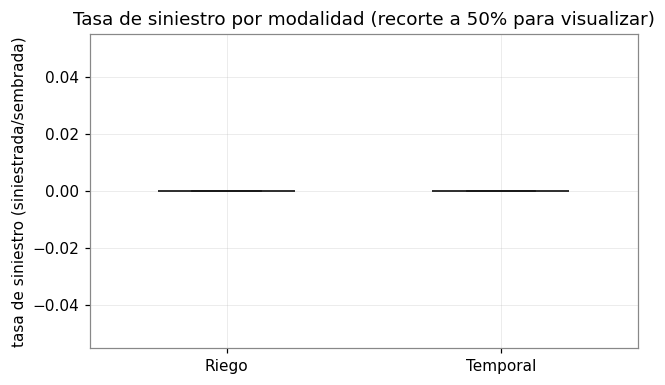


El riego reduce el siniestro frente a temporal (mecanismo esperado): confirma que
`nommodalidad` capta algo real sobre exposición al riesgo climático, no solo una etiqueta
administrativa -> respalda usarla como moderador del efecto de la sequía en 04_inferencia_causal.


In [13]:
# --- 2.10 · Mecanismo: tasa de siniestro por modalidad (¿el riego protege?) ---
print(df.groupby('nommodalidad')['tasa_siniestro'].describe()[['count', 'mean', '50%', 'max']].round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 3.6))
data = [df.loc[df.nommodalidad == m, 'tasa_siniestro'].clip(upper=0.5) for m in ['Riego', 'Temporal']]
bp = ax.boxplot(data, labels=['Riego', 'Temporal'], showfliers=False, patch_artist=True, widths=0.5)
for patch, m in zip(bp['boxes'], ['Riego', 'Temporal']):
    patch.set_facecolor(C_MODALIDAD[m]); patch.set_alpha(0.75)
for med in bp['medians']: med.set_color('#222')
ax.set_title('Tasa de siniestro por modalidad (recorte a 50% para visualizar)')
ax.set_ylabel('tasa de siniestro (siniestrada/sembrada)')
plt.tight_layout(); plt.show()

print('\nEl riego reduce el siniestro frente a temporal (mecanismo esperado): confirma que')
print('`nommodalidad` capta algo real sobre exposición al riesgo climático, no solo una etiqueta')
print('administrativa -> respalda usarla como moderador del efecto de la sequía en 04_inferencia_causal.')


## 3 · Resultado — `rendimiento_real` (t/ha)

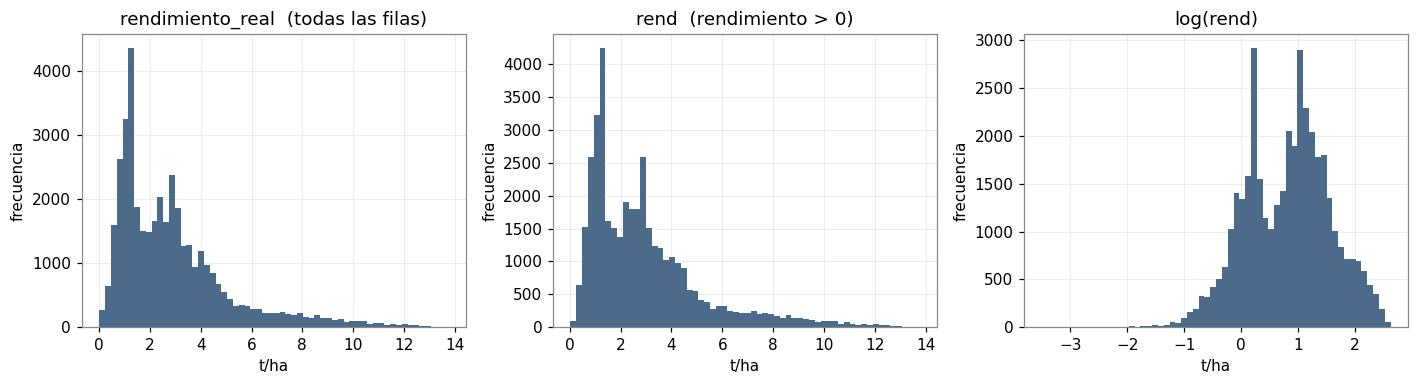

count    39247.000
mean         2.942
std          2.229
min          0.030
25%          1.250
50%          2.430
75%          3.810
max         13.750

asimetría (skew): rend=1.58  |  log(rend)=-0.15


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].hist(df['rendimiento_real'].dropna(), bins=60, color=C_NEUTRO)
axes[0].set_title('rendimiento_real  (todas las filas)')

axes[1].hist(df['rend'].dropna(), bins=60, color=C_NEUTRO)
axes[1].set_title('rend  (rendimiento > 0)')

axes[2].hist(np.log(df['rend'].dropna()), bins=60, color=C_NEUTRO)
axes[2].set_title('log(rend)')

for a in axes: a.set_xlabel('t/ha'); a.set_ylabel('frecuencia')
plt.tight_layout(); plt.show()

print(df['rend'].describe().round(3).to_string())
print(f"\nasimetría (skew): rend={df['rend'].skew():.2f}  |  log(rend)={np.log(df['rend']).skew():.2f}")


/var/folders/zl/8w22zx5911s93bs5f33hkp040000gn/T/ipykernel_86440/2737283973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=cats, showfliers=False, patch_artist=True, widths=0.5)
/var/folders/zl/8w22zx5911s93bs5f33hkp040000gn/T/ipykernel_86440/2737283973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=cats, showfliers=False, patch_artist=True, widths=0.5)


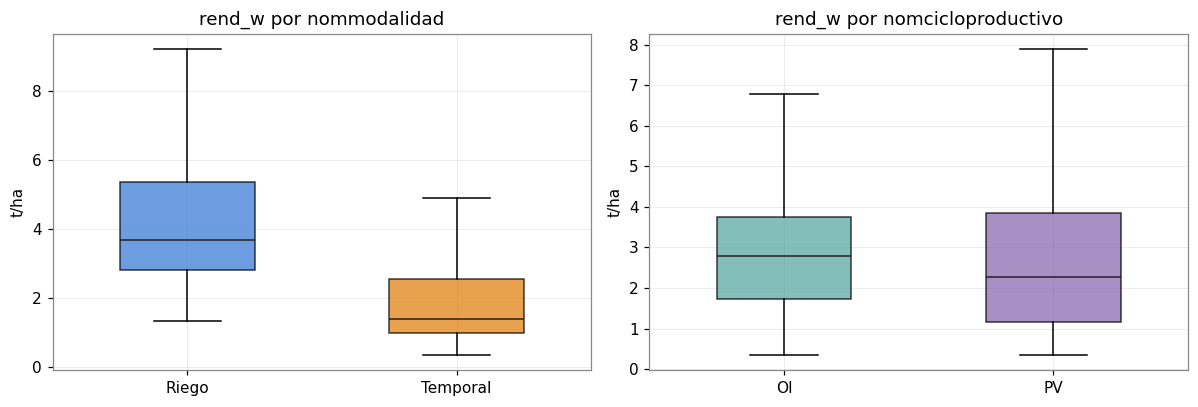

              count  median  mean   std
nommodalidad                           
Riego         15350    3.68  4.44  2.38
Temporal      23897    1.40  1.98  1.46

nommodalidad  nomcicloproductivo
Riego         OI                    3.33
              PV                    4.05
Temporal      OI                    1.60
              PV                    1.32


In [15]:
# rendimiento por modalidad y por ciclo
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, grp in zip(axes, ['nommodalidad', 'nomcicloproductivo']):
    cats = sorted(df[grp].dropna().unique())
    data = [df.loc[df[grp] == c, 'rend_w'].dropna() for c in cats]
    pal = C_MODALIDAD if grp == 'nommodalidad' else C_CICLO
    bp = ax.boxplot(data, labels=cats, showfliers=False, patch_artist=True, widths=0.5)
    for patch, c in zip(bp['boxes'], cats):
        patch.set_facecolor(pal[c]); patch.set_alpha(0.75)
    for med in bp['medians']: med.set_color('#222')
    ax.set_title(f'rend_w por {grp}'); ax.set_ylabel('t/ha')

plt.tight_layout(); plt.show()

print(df.groupby('nommodalidad')['rend'].agg(['count', 'median', 'mean', 'std']).round(2).to_string())
print()
print(df.groupby(['nommodalidad', 'nomcicloproductivo'])['rend'].median().round(2).to_string())


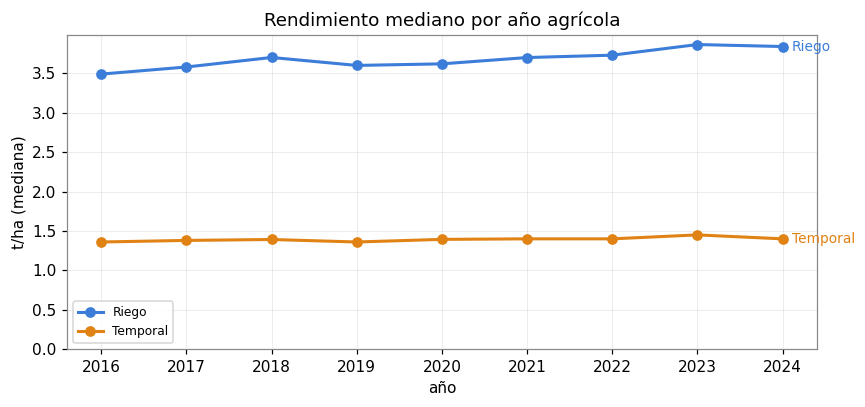

In [16]:
# rendimiento mediano por año, separando modalidad  (una serie por modalidad, un eje)
fig, ax = plt.subplots(figsize=(8, 3.8))
for m in ['Riego', 'Temporal']:
    s = df[df.nommodalidad == m].groupby('anio')['rend'].median()
    ax.plot(s.index, s.values, marker='o', lw=2, color=C_MODALIDAD[m], label=m)
    ax.annotate(m, (s.index[-1], s.values[-1]), color=C_MODALIDAD[m],
                fontsize=9, xytext=(6, 0), textcoords='offset points', va='center')
ax.set_title('Rendimiento mediano por año agrícola')
ax.set_xlabel('año'); ax.set_ylabel('t/ha (mediana)')
ax.set_ylim(bottom=0); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


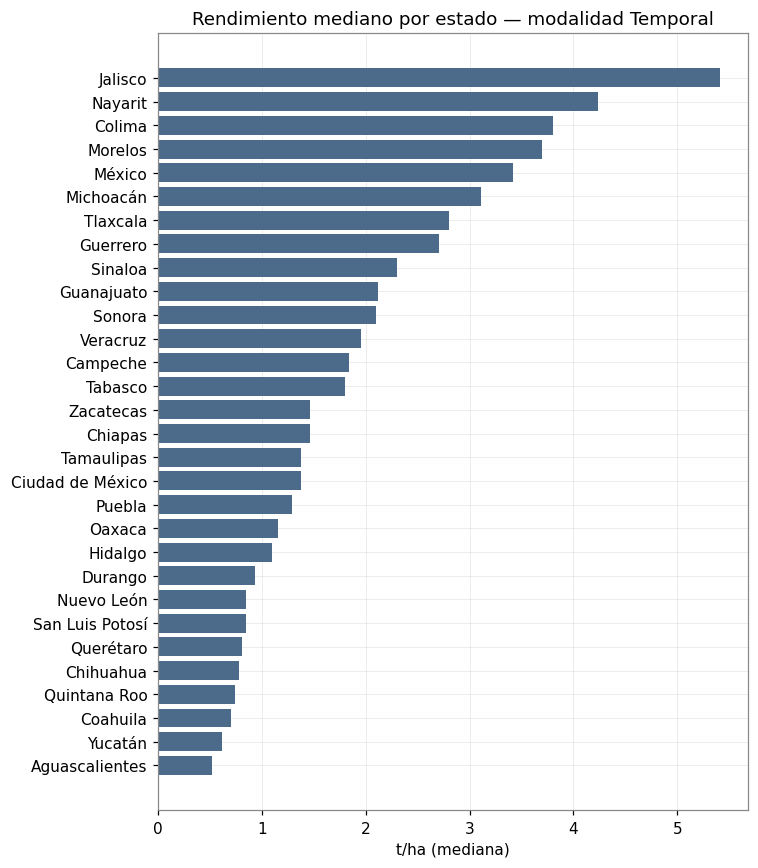

In [17]:
# top / bottom estados por rendimiento mediano (Temporal, el más expuesto a sequía)
tmp = (df[df.nommodalidad == 'Temporal']
       .groupby('nomestado')['rend'].median().dropna().sort_values())
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(tmp.index, tmp.values, color=C_NEUTRO)
ax.set_title('Rendimiento mediano por estado — modalidad Temporal')
ax.set_xlabel('t/ha (mediana)')
plt.tight_layout(); plt.show()


## 4 · Tratamiento — `nivel_sequia_max` y `nivel_sequia_prev90_max`

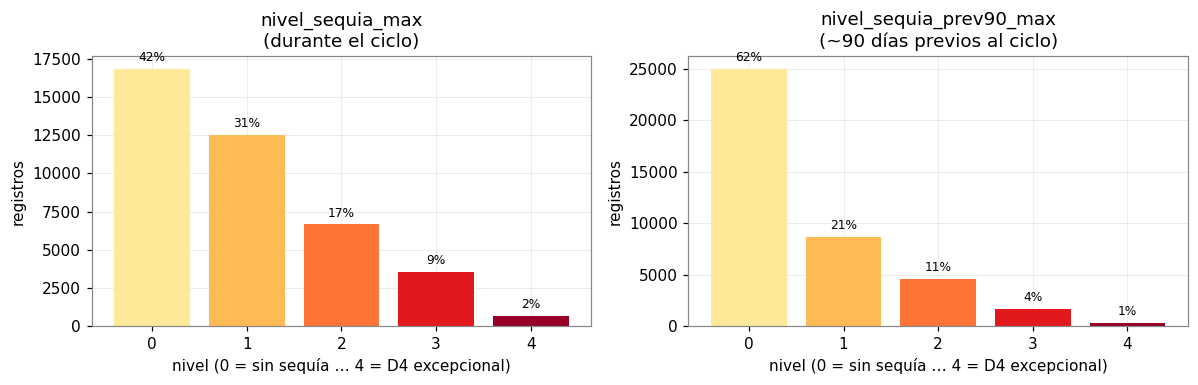

nivel_sequia_prev90_max     0     1     2     3     4
nivel_sequia_max                                     
0                        0.91  0.08  0.01  0.00  0.00
1                        0.59  0.35  0.05  0.01  0.00
2                        0.29  0.32  0.34  0.05  0.00
3                        0.10  0.21  0.37  0.29  0.01
4                        0.01  0.07  0.16  0.37  0.39

(fila = nivel durante el ciclo, columna = nivel en la ventana previa)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, ttl in zip(axes,
                        ['nivel_sequia_max', 'nivel_sequia_prev90_max'],
                        ['durante el ciclo', '~90 días previos al ciclo']):
    vc = df[col].value_counts().sort_index()
    colors = plt.get_cmap(CMAP_SEQ)(np.linspace(0.15, 0.95, len(vc)))
    ax.bar(vc.index, vc.values, color=colors)
    ax.bar_label(ax.containers[0], labels=[f'{v/len(df):.0%}' for v in vc.values], padding=3, fontsize=8)
    ax.set_title(f'{col}\n({ttl})')
    ax.set_xlabel('nivel (0 = sin sequía … 4 = D4 excepcional)')
    ax.set_ylabel('registros')
plt.tight_layout(); plt.show()

print(pd.crosstab(df['nivel_sequia_max'], df['nivel_sequia_prev90_max'],
                  normalize='index').round(2).to_string())
print('\n(fila = nivel durante el ciclo, columna = nivel en la ventana previa)')


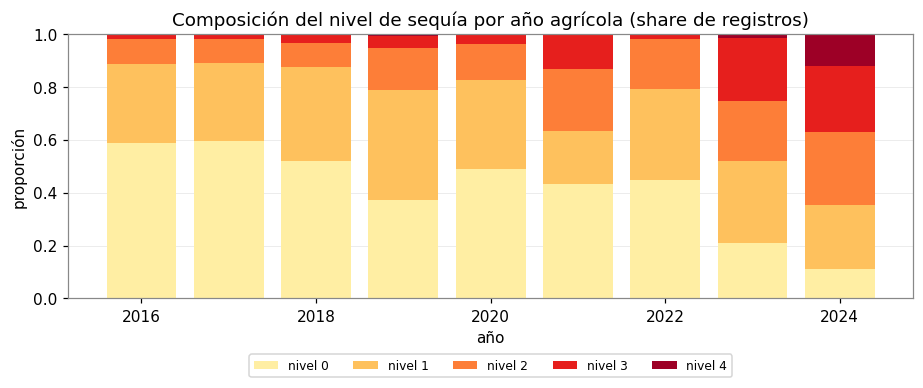

In [19]:
# evolución temporal de la severidad de sequía (share de cada nivel por año)
share = pd.crosstab(df['anio'], df['nivel_sequia_max'], normalize='index')
fig, ax = plt.subplots(figsize=(8.5, 3.8))
bottom = np.zeros(len(share))
cmap = plt.get_cmap(CMAP_SEQ)
for i, lvl in enumerate(share.columns):
    ax.bar(share.index, share[lvl], bottom=bottom, label=f'nivel {lvl}',
           color=cmap(0.12 + 0.82 * lvl / 4), width=0.8)
    bottom += share[lvl].values
ax.set_title('Composición del nivel de sequía por año agrícola (share de registros)')
ax.set_xlabel('año'); ax.set_ylabel('proporción'); ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.32))
plt.tight_layout(); plt.show()


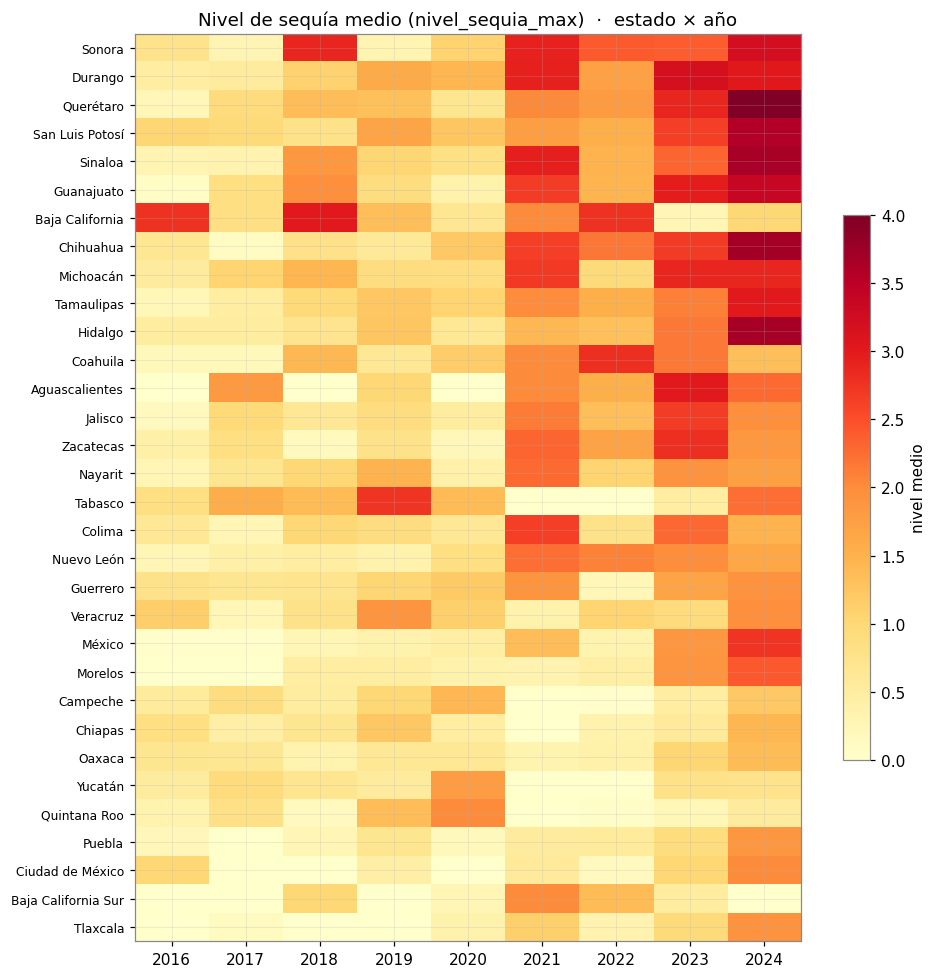

In [20]:
# heatmap estado x año del nivel medio de sequía
piv = df.pivot_table(index='nomestado', columns='anio', values='nivel_sequia_max', aggfunc='mean')
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(piv.values, aspect='auto', cmap=CMAP_SEQ, vmin=0, vmax=piv.values.max())
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=8)
ax.set_title('Nivel de sequía medio (nivel_sequia_max)  ·  estado × año')
fig.colorbar(im, ax=ax, shrink=0.6, label='nivel medio')
plt.tight_layout(); plt.show()


## 5 · Tratamiento ↔ resultado

/var/folders/zl/8w22zx5911s93bs5f33hkp040000gn/T/ipykernel_86440/2030327635.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=lvls, showfliers=False, patch_artist=True, widths=0.55)
/var/folders/zl/8w22zx5911s93bs5f33hkp040000gn/T/ipykernel_86440/2030327635.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=lvls, showfliers=False, patch_artist=True, widths=0.55)


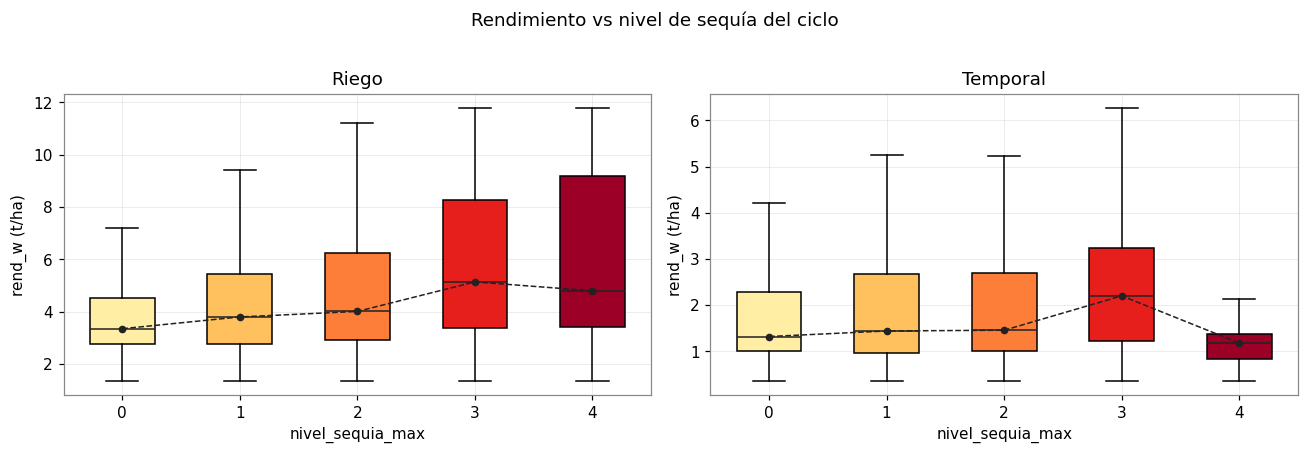

                               count  median  mean
nommodalidad nivel_sequia_max                     
Riego        0                  6923    3.35  3.99
             1                  4545    3.80  4.46
             2                  2304    4.01  4.77
             3                  1362    5.14  5.84
             4                   216    4.80  6.20
Temporal     0                  9710    1.32  1.80
             1                  7684    1.44  2.04
             2                  4137    1.46  2.09
             3                  1969    2.20  2.53
             4                   397    1.18  1.23


In [21]:
# rend_w por nivel de sequía, separado por modalidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, m in zip(axes, ['Riego', 'Temporal']):
    sub = df[df.nommodalidad == m]
    lvls = sorted(sub['nivel_sequia_max'].unique())
    data = [sub.loc[sub.nivel_sequia_max == l, 'rend_w'].dropna() for l in lvls]
    cmap = plt.get_cmap(CMAP_SEQ)
    bp = ax.boxplot(data, labels=lvls, showfliers=False, patch_artist=True, widths=0.55)
    for patch, l in zip(bp['boxes'], lvls):
        patch.set_facecolor(cmap(0.12 + 0.82 * l / 4))
    for med in bp['medians']: med.set_color('#222')
    med_by = [np.median(d) for d in data]
    ax.plot(range(1, len(lvls)+1), med_by, color='#222', lw=1, ls='--', marker='o', ms=4)
    ax.set_title(f'{m}'); ax.set_xlabel('nivel_sequia_max'); ax.set_ylabel('rend_w (t/ha)')
fig.suptitle('Rendimiento vs nivel de sequía del ciclo', y=1.02)
plt.tight_layout(); plt.show()

print(df.groupby(['nommodalidad', 'nivel_sequia_max'])['rend']
      .agg(['count', 'median', 'mean']).round(2).to_string())


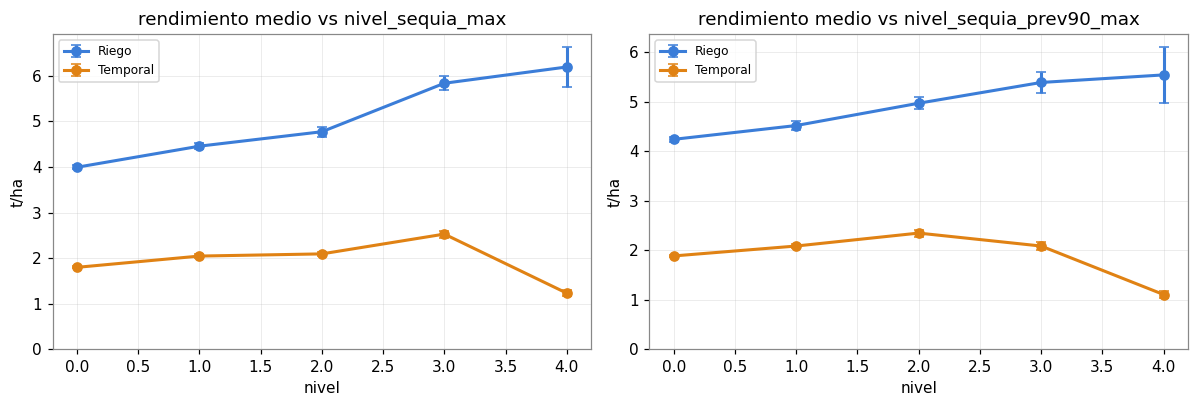

In [22]:
# media de rendimiento (limpio) por nivel de sequía, con error estándar
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col in zip(axes, ['nivel_sequia_max', 'nivel_sequia_prev90_max']):
    g = df.groupby(['nommodalidad', col])['rend']
    m = g.mean().unstack(0); se = (g.std() / np.sqrt(g.count())).unstack(0)
    for mod in ['Riego', 'Temporal']:
        ax.errorbar(m.index, m[mod], yerr=1.96*se[mod], marker='o', lw=2, capsize=3,
                    color=C_MODALIDAD[mod], label=mod)
    ax.set_title(f'rendimiento medio vs {col}')
    ax.set_xlabel('nivel'); ax.set_ylabel('t/ha'); ax.set_ylim(bottom=0); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [23]:
# correlación (Spearman) tratamiento-resultado, global y por estrato
from scipy.stats import spearmanr

def _sp(a, b):
    m = a.notna() & b.notna()
    return spearmanr(a[m], b[m]).statistic if m.sum() > 30 else np.nan

print('Spearman(nivel_sequia_max, rend):')
print(f'  global            : {_sp(df.nivel_sequia_max, df.rend):+.3f}')
for m in ['Riego', 'Temporal']:
    s = df[df.nommodalidad == m]
    print(f'  {m:8s}          : {_sp(s.nivel_sequia_max, s.rend):+.3f}')
for c in ['OI', 'PV']:
    s = df[df.nomcicloproductivo == c]
    print(f'  ciclo {c}          : {_sp(s.nivel_sequia_max, s.rend):+.3f}')
print(f'\nSpearman(nivel_sequia_prev90_max, rend) global: {_sp(df.nivel_sequia_prev90_max, df.rend):+.3f}')


Spearman(nivel_sequia_max, rend):
  global            : +0.068
  Riego             : +0.185
  Temporal          : +0.077
  ciclo OI          : -0.007
  ciclo PV          : +0.111

Spearman(nivel_sequia_prev90_max, rend) global: +0.067


## 6 · Confusores — distribuciones y correlaciones

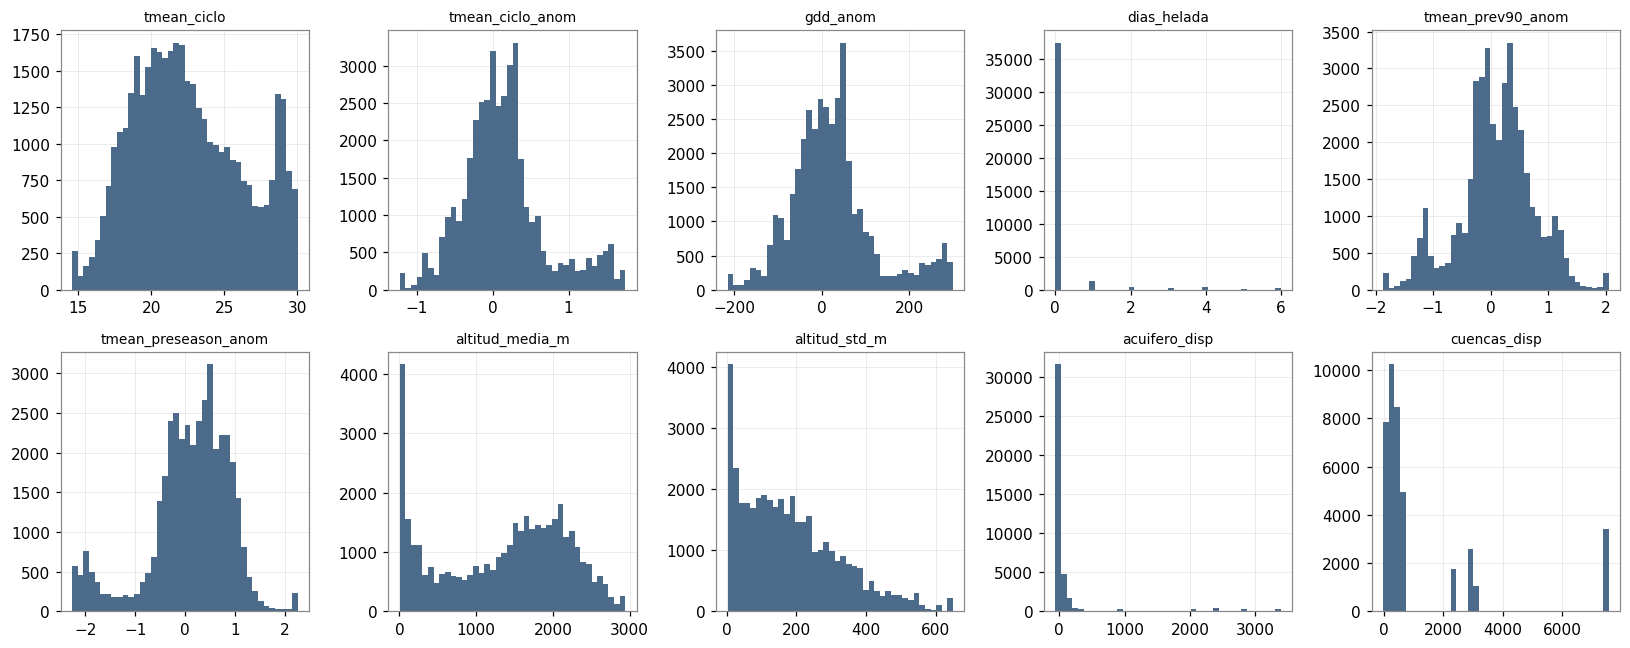

binarios:
  tiene_acuifero_sobreexplotado: 22.0% de las filas = 1
  tiene_cuenca_sin_disp: 49.0% de las filas = 1


In [24]:
conf_cols = ['tmean_ciclo', 'tmean_ciclo_anom', 'gdd_anom', 'dias_helada',
             'tmean_prev90_anom', 'tmean_preseason_anom',
             'altitud_media_m', 'altitud_std_m', 'acuifero_disp', 'cuencas_disp']
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, c in zip(axes.flat, conf_cols):
    s = df[c].dropna()
    lo, hi = s.quantile([0.005, 0.995])
    ax.hist(s.clip(lo, hi), bins=40, color=C_NEUTRO)
    ax.set_title(c, fontsize=9)
plt.tight_layout(); plt.show()

print('binarios:')
for c in ['tiene_acuifero_sobreexplotado', 'tiene_cuenca_sin_disp']:
    print(f'  {c}: {df[c].mean():.1%} de las filas = 1')


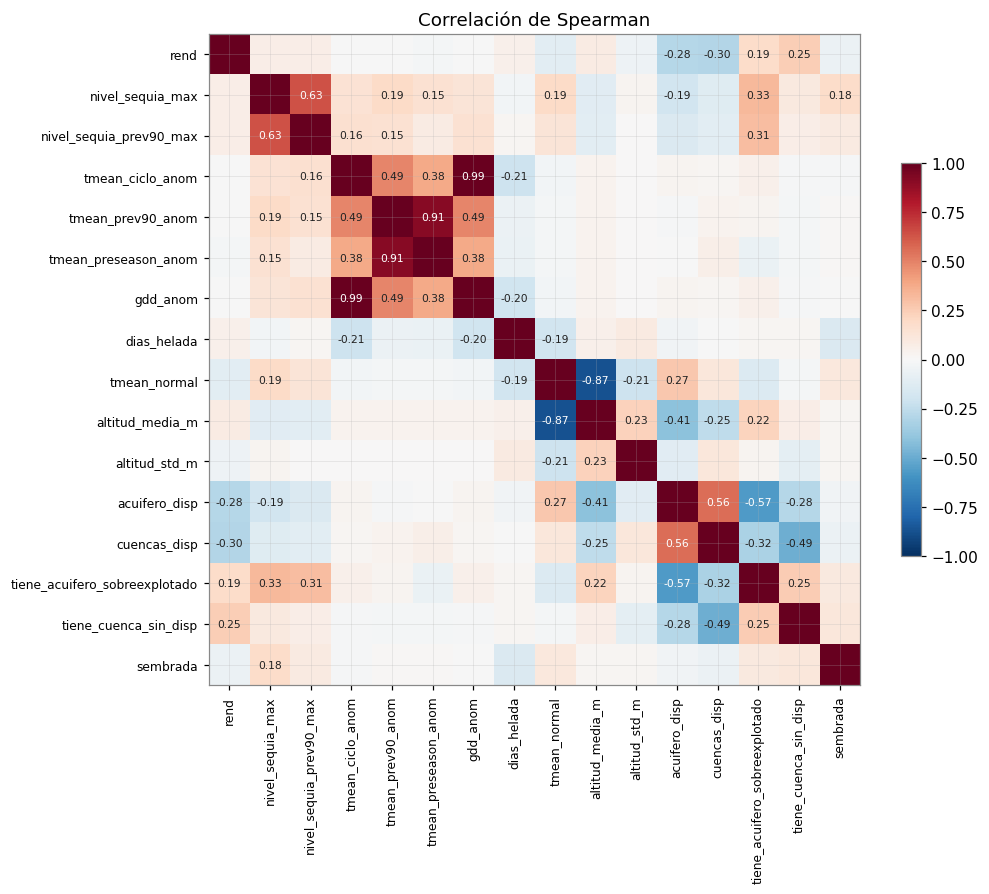

pares con |Spearman| > 0.8 (redundantes -> elegir solo uno al modelar):
tmean_ciclo_anom   gdd_anom                0.986
tmean_prev90_anom  tmean_preseason_anom    0.914
tmean_normal       altitud_media_m        -0.870


In [25]:
# matriz de correlación (Spearman) de las variables numéricas clave
keys = ['rend', 'nivel_sequia_max', 'nivel_sequia_prev90_max',
        'tmean_ciclo_anom', 'tmean_prev90_anom', 'tmean_preseason_anom', 'gdd_anom', 'dias_helada',
        'tmean_normal', 'altitud_media_m', 'altitud_std_m',
        'acuifero_disp', 'cuencas_disp', 'tiene_acuifero_sobreexplotado', 'tiene_cuenca_sin_disp',
        'sembrada']
corr = df[keys].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=90, fontsize=8)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys, fontsize=8)
for i in range(len(keys)):
    for j in range(len(keys)):
        v = corr.values[i, j]
        if abs(v) >= 0.15 and i != j:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.55 else '#222')
ax.set_title('Correlación de Spearman')
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()

# escaneo automático de redundancia: cualquier par con |Spearman| > 0.8 (candidatos a NO meter juntos)
pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
altos = pares[pares.abs() > 0.8].sort_values(key=lambda s: s.abs(), ascending=False)
print('pares con |Spearman| > 0.8 (redundantes -> elegir solo uno al modelar):')
print(altos.round(3).to_string() if len(altos) else '  (ninguno)')


In [26]:
# --- Descomposición de varianza: ¿cuánta de la variación de cada confusor es DENTRO de
#     municipio (a través de los años) vs ENTRE municipios? Relevante para un modelo con
#     efectos fijos de municipio (04_inferencia_causal): si casi toda la varianza es "entre",
#     el EF de municipio absorbe la variable y queda poca señal temporal para identificar.
cols_panel = ['acuifero_disp', 'cuencas_disp', 'tmean_ciclo_anom', 'tmean_prev90_anom', 'altitud_media_m']
filas = []
for c in cols_panel:
    s = df[c].dropna()
    gm = df.loc[s.index].groupby(['idestado', 'idmunicipio'])[c].transform('mean')
    var_total = s.var()
    var_dentro = (s - gm).var()
    filas.append(dict(variable=c, var_total=var_total, var_dentro=var_dentro,
                      pct_dentro=var_dentro / var_total if var_total else np.nan))
tab_var = pd.DataFrame(filas).round(4)
tab_var['pct_dentro'] = (tab_var['pct_dentro'] * 100).round(1)
print(tab_var.to_string(index=False))
print()
print('% dentro BAJO (p.ej. acuifero_disp) -> la variable es casi puramente "de municipio":')
print('con EF de municipio activado, aporta poquísima variación temporal para identificar el')
print('efecto de la sequía; altitud_media_m (invariante) debería salir en ~0%, referencia.')


         variable    var_total   var_dentro  pct_dentro
    acuifero_disp  209548.2197    6710.7443         3.2
     cuencas_disp 4379014.6194 1251048.5231        28.6
 tmean_ciclo_anom       0.3167       0.3135        99.0
tmean_prev90_anom       0.4936       0.4863        98.5
  altitud_media_m  691555.8421       0.0000         0.0

% dentro BAJO (p.ej. acuifero_disp) -> la variable es casi puramente "de municipio":
con EF de municipio activado, aporta poquísima variación temporal para identificar el
efecto de la sequía; altitud_media_m (invariante) debería salir en ~0%, referencia.


## 7 · Chequeo de confusión — ¿varían los confusores con el tratamiento?

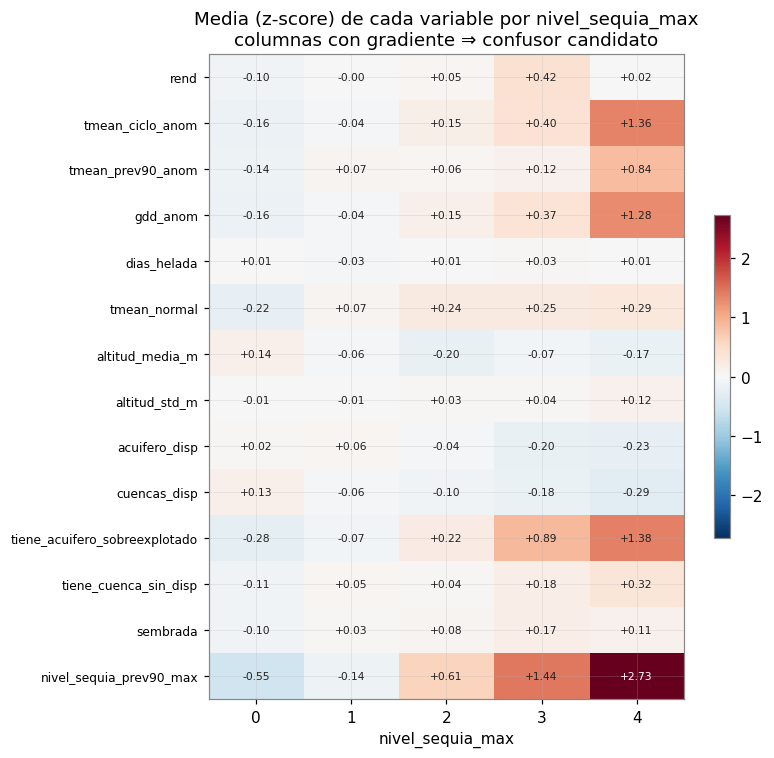

In [27]:
# media (estandarizada) de cada confusor por nivel_sequia_max
conf = ['rend', 'tmean_ciclo_anom', 'tmean_prev90_anom', 'gdd_anom', 'dias_helada',
        'tmean_normal', 'altitud_media_m', 'altitud_std_m',
        'acuifero_disp', 'cuencas_disp', 'tiene_acuifero_sobreexplotado',
        'tiene_cuenca_sin_disp', 'sembrada', 'nivel_sequia_prev90_max']
z = (df[conf] - df[conf].mean()) / df[conf].std()
z['nivel_sequia_max'] = df['nivel_sequia_max']
tab = z.groupby('nivel_sequia_max').mean().T

fig, ax = plt.subplots(figsize=(7.5, 7))
lim = np.nanmax(np.abs(tab.values))
im = ax.imshow(tab.values, cmap=CMAP_DIV, vmin=-lim, vmax=lim, aspect='auto')
ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels(tab.columns)
ax.set_yticks(range(tab.shape[0])); ax.set_yticklabels(tab.index, fontsize=8)
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        ax.text(j, i, f'{tab.values[i, j]:+.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(tab.values[i, j]) > lim*0.6 else '#222')
ax.set_title('Media (z-score) de cada variable por nivel_sequia_max\n'
             'columnas con gradiente ⇒ confusor candidato')
ax.set_xlabel('nivel_sequia_max')
fig.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout(); plt.show()


In [28]:
# resumen: correlación de cada variable con el TRATAMIENTO y con el RESULTADO
rows = []
for c in [x for x in keys if x not in ('rend', 'nivel_sequia_max')]:
    rows.append({
        'variable': c,
        'corr_con_tratamiento': df[[c, 'nivel_sequia_max']].corr('spearman').iloc[0, 1],
        'corr_con_resultado':   df[[c, 'rend']].corr('spearman').iloc[0, 1],
    })
tab = (pd.DataFrame(rows)
       .assign(rel_confusion=lambda d: d.corr_con_tratamiento.abs() * d.corr_con_resultado.abs())
       .sort_values('rel_confusion', ascending=False)
       .round(3))
print(tab.to_string(index=False))
print('\nrel_confusion alto = la variable se asocia a la vez con el tratamiento y con el rendimiento')
print('=> candidata firme a incluir como control en el modelo causal.')


                     variable  corr_con_tratamiento  corr_con_resultado  rel_confusion
tiene_acuifero_sobreexplotado                 0.327               0.187          0.061
                acuifero_disp                -0.188              -0.282          0.053
      nivel_sequia_prev90_max                 0.635               0.067          0.042
                 cuencas_disp                -0.124              -0.295          0.037
        tiene_cuenca_sin_disp                 0.094               0.247          0.023
                 tmean_normal                 0.194              -0.104          0.020
                     sembrada                 0.181              -0.061          0.011
              altitud_media_m                -0.111               0.085          0.009
         tmean_preseason_anom                 0.153              -0.023          0.003
                  dias_helada                -0.026               0.054          0.001
                altitud_std_m              

## 8 · Serie temporal

      rend_mediano  pct_sequia_moderada_o_peor  pct_prev90_moderada_o_peor
anio                                                                      
2016         2.300                       0.114                       0.050
2017         2.310                       0.109                       0.080
2018         2.356                       0.126                       0.062
2019         2.470                       0.211                       0.073
2020         2.400                       0.172                       0.130
2021         2.480                       0.366                       0.293
2022         2.500                       0.208                       0.054
2023         2.600                       0.481                       0.207
2024         2.500                       0.645                       0.531


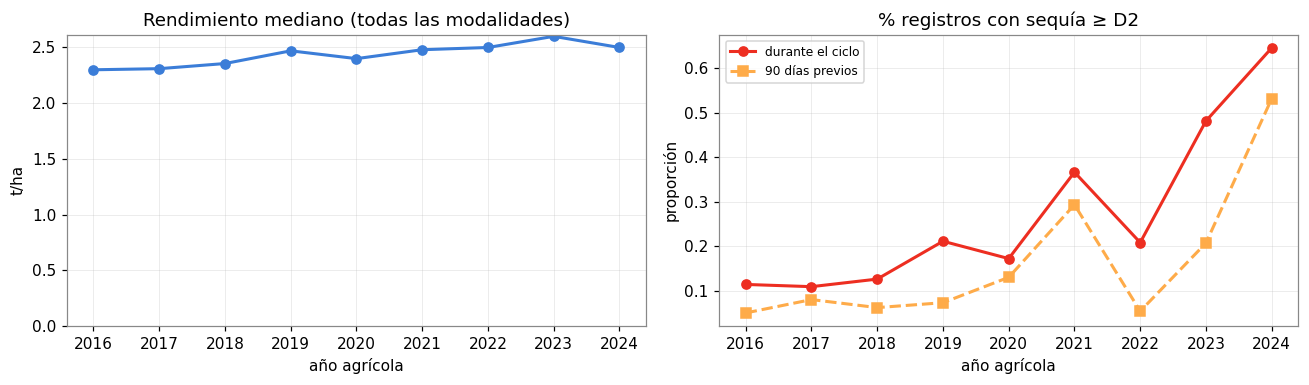

In [29]:
resumen_anual = df.groupby('anio').agg(
    rend_mediano=('rend', 'median'),
    pct_sequia_moderada_o_peor=('nivel_sequia_max', lambda s: (s >= 2).mean()),
    pct_prev90_moderada_o_peor=('nivel_sequia_prev90_max', lambda s: (s >= 2).mean()),
).round(3)
print(resumen_anual.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(resumen_anual.index, resumen_anual.rend_mediano, marker='o', lw=2, color=C_MODALIDAD['Riego'])
axes[0].set_title('Rendimiento mediano (todas las modalidades)'); axes[0].set_ylabel('t/ha'); axes[0].set_ylim(bottom=0)

axes[1].plot(resumen_anual.index, resumen_anual.pct_sequia_moderada_o_peor, marker='o', lw=2,
             color=plt.get_cmap(CMAP_SEQ)(0.7), label='durante el ciclo')
axes[1].plot(resumen_anual.index, resumen_anual.pct_prev90_moderada_o_peor, marker='s', lw=2, ls='--',
             color=plt.get_cmap(CMAP_SEQ)(0.4), label='90 días previos')
axes[1].set_title('% registros con sequía ≥ D2'); axes[1].set_ylabel('proporción'); axes[1].legend(fontsize=8)

for a in axes: a.set_xlabel('año agrícola')
plt.tight_layout(); plt.show()


## 9 · Hallazgos

### Calidad de datos
- `rendimiento_real` **corregido**: ahora es `volumenproduccion / cosechada` (definición SIAP). En los datos `sembrada = cosechada + siniestrada` se cumple exacto, así que `cosechada` ya es superficie neta. Rango **0 – 13.75 t/ha**, coherente con maíz (SIAP tope ~15).
  - 169 filas (0.4 %) con **cosecha total nula** (`rendimiento_real = 0`) y **1 020 filas (2.5 %)** con **tasa de siniestro** (`siniestrada/sembrada`) **≥ 50 %** (corte fijo, calculado en `02_join_data`) — ambas quedan fuera del análisis de rendimiento (`siniestro_ok`).
  - `rend` = `rendimiento_real` > 0 **y** `siniestro_ok` → **39 247 filas (97.5 %)**;  `rend_w` = winsorizado p1–p99 por modalidad.
- 95 filas sin clima (`clima_ok = False`); **4 021 (10 %)** con sequía no clasificada por el Monitor (imputada a 0, `sequia_no_clasificada`); 10 463 sin clasificar en la ventana previa.
- **`acuifero_condicion_ok = 0` en 2016-2019 (17 866 filas, 44 %)**: CONAGUA no publicó la columna `Condición` en los xlsx de 2015/2018 → `tiene_acuifero_sobreexplotado` sale en 0 ahí por **falta de dato**, no porque no hubiera sobreexplotación. No tomar esas filas como "sin sobreexplotación" real.
- **Panel desbalanceado**: solo el 31.7 % de las combinaciones municipio-año-ciclo tienen **ambas** modalidades (Riego y Temporal); solo 30 de 2 386 municipios (1.3 %) traen las 36 filas teóricas (9 años × 2 ciclos × 2 modalidades). Un modelo con EF de municipio tiene menos variación "dentro" de la que parece.
- Filas aptas para el modelo (todos los bloques ok & sequía clasificada): **36 155 (89.8 %)**, 2 382 municipios.

### Resultado
- Separación fuerte por modalidad: **Riego ≈ 3.7 t/ha vs Temporal ≈ 1.4 t/ha** de mediana (≈ 2.7×). Todo análisis debe estratificar o controlar por `nommodalidad`.
- `rend` moderadamente asimétrica a la derecha (skew 1.6); `log(rend)` la simetriza (skew −0.2) → análisis primario en logaritmo.
- Sin tendencia temporal clara del rendimiento mediano 2016–2024.
- **Mecanismo confirmado**: la tasa de siniestro media es 0.5 % en Riego vs 4.7 % en Temporal — el riego protege contra la pérdida de cosecha, como se esperaría. Respalda usar `nommodalidad` como moderador real (no solo etiqueta administrativa).

### Tratamiento
- `nivel_sequia_max` concentrado en 0–1 (≈ 73 %); D3–D4 minoría (≈ 10 %). Años y estados pico visibles en el heatmap estado × año.
- `nivel_sequia_prev90_max` fuertemente correlacionado con el del ciclo (**Spearman 0.63**) — sequía persistente.

### Señal causal preliminar — ¡ojo!
- La asociación **cruda** sequía → rendimiento es **positiva**: Spearman **+0.054** global (+0.19 Riego, +0.06 Temporal, +0.09 PV). Sin ajustar, "más sequía" viene con "más rendimiento".
- Es **confusión**, no efecto: las zonas secas (norte) concentran riego, mayor productividad de base y un régimen de sequía persistente. Justifica el ajuste causal (ver `04_inferencia_causal`).

### Confusores (`rel_confusion` = |corr con tratamiento| × |corr con resultado|)
Candidatos firmes, en orden: **`acuifero_disp`** (−0.16 / −0.27), **`nivel_sequia_prev90_max`** (0.63 / 0.06), **`tiene_acuifero_sobreexplotado`**, **`cuencas_disp`**, **`tiene_cuenca_sin_disp`**, **`tmean_normal`**.

### Redundancias — elegir una variable de cada par
- `gdd_anom` ≈ `tmean_ciclo_anom`  (Spearman ~0.99)
- `tmean_prev90_anom` ≈ `tmean_preseason_anom`  (~0.91) — nuevo; no meterlas juntas en un modelo
- `altitud_media_m` ≈ −`tmean_normal`  (~−0.87)
- `acuifero_disp` ≈ −`tiene_acuifero_sobreexplotado`  (~−0.83)

### Descomposición de varianza (entre vs dentro de municipio)
- `acuifero_disp` es **97 % "entre municipios"** (solo 3.2 % de su varianza es dentro de municipio, año a año); `cuencas_disp` algo más móvil (28.6 % dentro). Con EF de municipio (`04_inferencia_causal`, TWFE) estas variables aportan poquísima señal temporal — casi todo su contenido informativo ya lo captura el efecto fijo. Explica por qué el AIPW es más sensible que el TWFE a cómo se tratan estas covariables.

### Siguientes pasos
1. Modelar `log(rend)` con las 36 155 filas aptas, EF de municipio y año, controlando la sequía antecedente.
2. Estratificar por `nommodalidad` o incluir su interacción con `nivel_sequia_max`.
3. Excluir del ajuste variables post‑tratamiento (`cosechada`, `siniestrada`, `volumenproduccion`).
